<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan1/blob/main/Greedy_Beasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greedy Beasiswa Colab

Upload Dataset (.csv)


Saving Dataset Laporan Pengganti Kehadiran.csv to Dataset Laporan Pengganti Kehadiran (6).csv

DATASET BERHASIL DIBACA
Jumlah Data : 100
Jumlah Kolom : 15

Nama Kolom
['ID_Mahasiswa', 'Semester', 'Jenis_Kelamin', 'Wilayah', 'Jumlah_Anggota_Keluarga', 'Program_Studi', 'Perguruan_Tinggi', 'Kota_Asal', 'Pendidikan_Orang_Tua', 'Pendapatan_Keluarga', 'Total_SKS_Lulus', 'Jam_Belajar_per_Minggu', 'Persentase_Kehadiran', 'Nilai_UTS', 'Nilai_UAS']

HASIL GREEDY


,ID_Mahasiswa,Semester,Jenis_Kelamin,Wilayah,Jumlah_Anggota_Keluarga,Program_Studi,Perguruan_Tinggi,Kota_Asal,Pendidikan_Orang_Tua,Pendapatan_Keluarga,Total_SKS_Lulus,Jam_Belajar_per_Minggu,Persentase_Kehadiran,Nilai_UTS,Nilai_UAS,Nilai_Akademik,Skor,Status,Ranking
0,26,6,Perempuan,Perkotaan,7,Electrical Engineering,Benha University,Asyut,No Education,Upper-Middle,102,7.3,100.0,89.8,75.2,82.50,87.750,1,1
1,6,7,Laki-laki,Perkotaan,4,Civil Engineering,Sohag University,Zagazig,Postgraduate,Upper-Middle,91,37.8,89.7,85.7,85.5,85.60,86.830,1,2
2,97,2,Perempuan,Perkotaan,2,Biology,Benha University,Rosetta,Diploma,Middle,26,21.5,100.0,77.7,83.7,80.70,86.490,1,3
3,19,7,Laki-laki,Pedesaan,2,Chemistry,Sohag University,Zagazig,Bachelor,Middle,105,29.0,91.4,80.4,87.2,83.80,86.080,1,4
4,46,8,Perempuan,Pedesaan,8,Literature,Suez Canal University,Cairo,Secondary,Lower-Middle,112,20.7,84.3,86.7,83.7,85.20,84.930,1,5
5,54,4,Perempuan,Pedesaan,4,Mechanical Engineering,Zagazig University,Tanta,Bachelor,Rendah,48,21.1,100.0,83.6,69.7,76.65,83.655,1,6
6,99,6,Laki-laki,Perkotaan,3,Medicine,Alexandria University,Aswan,Bachelor,Lower-Middle,102,24.2,91.7,78.7,81.5,80.10,83.580,1,7
7,23,2,Perempuan,Perkotaan,4,Sociology,Damanhour University,Tahta,Secondary,Middle,30,18.3,93.9,77.0,81.3,79.15,83.575,1,8
8,77,3,Laki-laki,Pedesaan,3,Mathematics,Ain Shams University,Desouk,Postgraduate,Middle,42,32.7,88.2,82.0,80.1,81.05,83.195,1,9
9,85,6,Laki-laki,Pedesaan,2,Medicine,BUE,Esna,Primary,Middle,78,15.2,100.0,70.3,80.7,75.50,82.850,1,10



STATISTIK
Jumlah Mahasiswa : 100
Layak : 22
Tidak Layak : 78
Persentase Layak : 22.0 %
Persentase Tidak Layak : 78.0 %


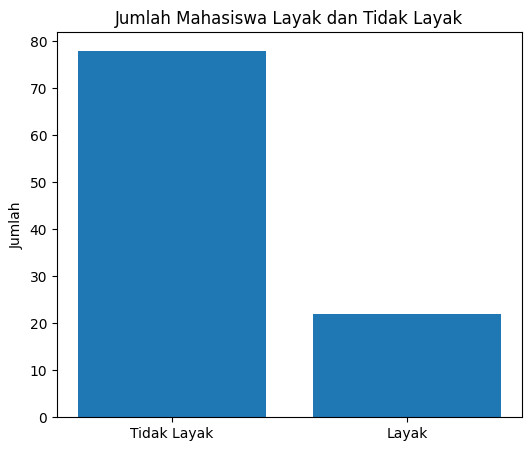

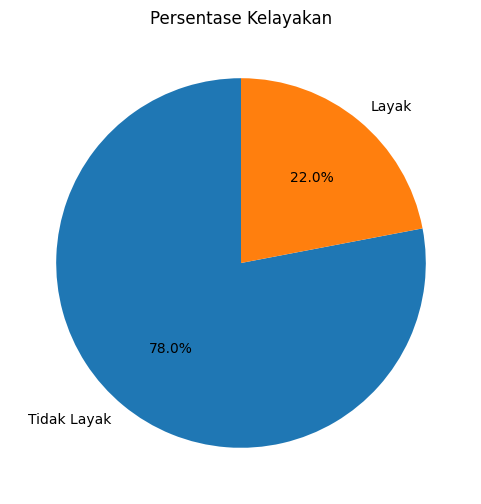

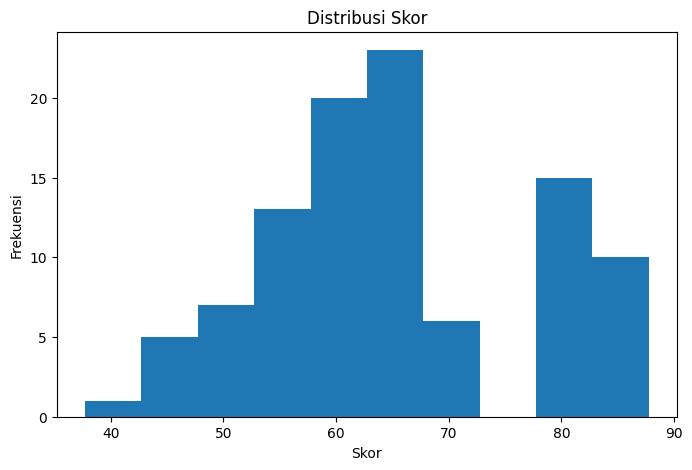

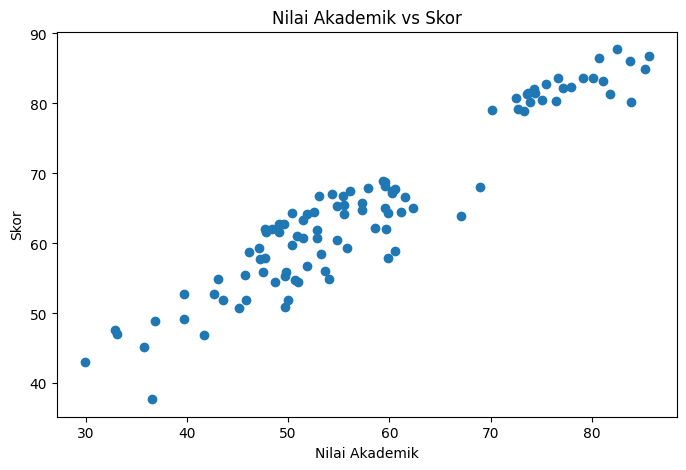

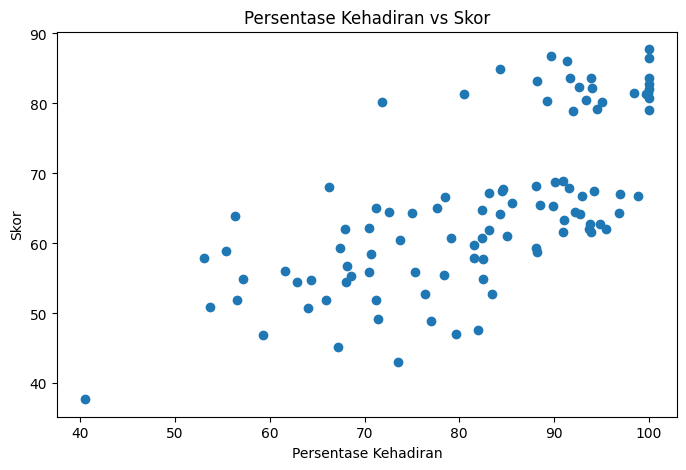

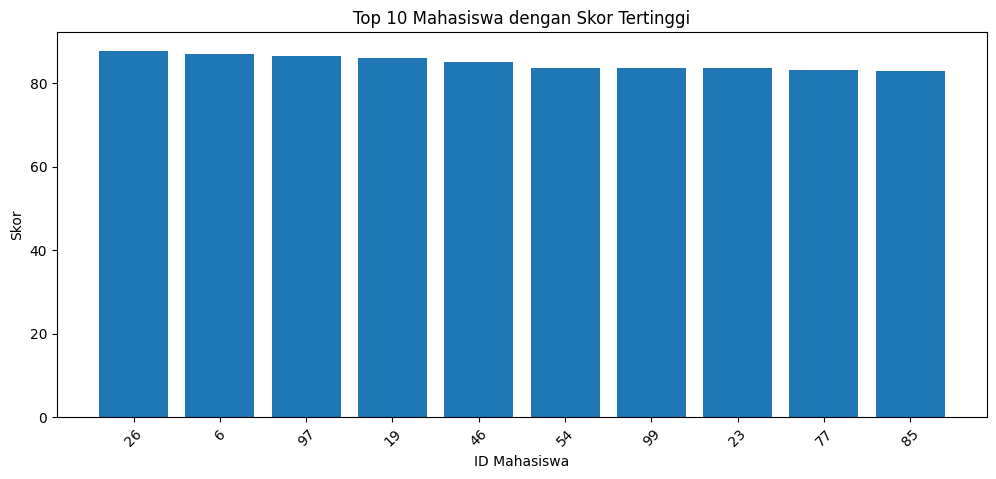


STATISTIK DESKRIPTIF


,Nilai_UTS,Nilai_UAS,Persentase_Kehadiran,Nilai_Akademik,Skor
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,56.953000,58.924000,81.901000,57.938500,65.127250
std,13.720525,14.662507,13.493826,13.496827,11.747104
min,33.000000,5.600000,40.500000,29.950000,37.735000
25%,47.175000,50.375000,71.350000,49.087500,56.570000
50%,54.100000,57.150000,83.900000,55.150000,64.000000
75%,67.700000,68.850000,92.775000,69.200000,71.378750
max,89.800000,89.900000,100.000000,85.600000,87.750000



FILE BERHASIL DIBUAT
1. Hasil_Greedy_Beasiswa.csv
2. Hasil_Greedy_Beasiswa.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PROGRAM SELESAI


In [9]:
# ============================================================
# PENENTUAN KELAYAKAN BEASISWA
# MENGGUNAKAN ALGORITMA GREEDY
# ============================================================

# ============================================================
# INSTALL LIBRARY
# ============================================================

!pip -q install openpyxl

# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# ============================================================
# UPLOAD DATASET
# ============================================================

print("Upload Dataset (.csv)")
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]

# ============================================================
# MEMBACA DATASET
# ============================================================

try:
    df = pd.read_csv(nama_file, sep=";")
except:
    df = pd.read_csv(nama_file)

# Menghapus spasi nama kolom
df.columns = df.columns.str.strip()

print("\n===================================================")
print("DATASET BERHASIL DIBACA")
print("===================================================")

print("Jumlah Data :", len(df))
print("Jumlah Kolom :", len(df.columns))

print("\nNama Kolom")
print(df.columns.tolist())

# ============================================================
# KOLOM WAJIB
# ============================================================

kolom = [
    "Nilai_UTS",
    "Nilai_UAS",
    "Persentase_Kehadiran"
]

for i in kolom:

    if i not in df.columns:

        raise Exception(f"Kolom {i} tidak ditemukan.")

# ============================================================
# KONVERSI NUMERIK
# ============================================================

for i in kolom:

    df[i] = (
        df[i]
        .astype(str)
        .str.replace(",",".",regex=False)
    )

    df[i] = pd.to_numeric(
        df[i],
        errors="coerce"
    )

df.fillna(0,inplace=True)

# ============================================================
# NILAI AKADEMIK
# ============================================================

df["Nilai_Akademik"] = (
    df["Nilai_UTS"] +
    df["Nilai_UAS"]
)/2

# ============================================================
# SKOR
# ============================================================

df["Skor"] = (
    (0.7 * df["Nilai_Akademik"]) +
    (0.3 * df["Persentase_Kehadiran"])
)

# ============================================================
# GREEDY
# ============================================================

hasil = df.sort_values(
    by="Skor",
    ascending=False
).reset_index(drop=True)

# ============================================================
# STATUS
# ============================================================

hasil["Status"] = np.where(
    hasil["Skor"]>=80,
    1,
    0
)

hasil["Ranking"] = hasil.index+1

# ============================================================
# MENAMPILKAN HASIL
# ============================================================

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

print("\n===================================================")
print("HASIL GREEDY")
print("===================================================")

display(hasil)

# ============================================================
# STATISTIK
# ============================================================

jumlah = len(hasil)

layak = (hasil["Status"]==1).sum()

tidak = (hasil["Status"]==0).sum()

print("\n===================================================")
print("STATISTIK")
print("===================================================")

print("Jumlah Mahasiswa :",jumlah)
print("Layak :",layak)
print("Tidak Layak :",tidak)

print("Persentase Layak :",
      round((layak/jumlah)*100,2),"%")

print("Persentase Tidak Layak :",
      round((tidak/jumlah)*100,2),"%")

# ============================================================
# GRAFIK 1
# ============================================================

plt.figure(figsize=(6,5))

plt.bar(
    ["Tidak Layak","Layak"],
    [tidak,layak]
)

plt.title("Jumlah Mahasiswa Layak dan Tidak Layak")
plt.ylabel("Jumlah")
plt.show()

# ============================================================
# GRAFIK 2
# ============================================================

plt.figure(figsize=(6,6))

plt.pie(
    [tidak,layak],
    labels=["Tidak Layak","Layak"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Persentase Kelayakan")

plt.show()

# ============================================================
# GRAFIK 3
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    hasil["Skor"],
    bins=10
)

plt.title("Distribusi Skor")

plt.xlabel("Skor")

plt.ylabel("Frekuensi")

plt.show()

# ============================================================
# GRAFIK 4
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    hasil["Nilai_Akademik"],
    hasil["Skor"]
)

plt.title("Nilai Akademik vs Skor")

plt.xlabel("Nilai Akademik")

plt.ylabel("Skor")

plt.show()

# ============================================================
# GRAFIK 5
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    hasil["Persentase_Kehadiran"],
    hasil["Skor"]
)

plt.title("Persentase Kehadiran vs Skor")

plt.xlabel("Persentase Kehadiran")

plt.ylabel("Skor")

plt.show()

# ============================================================
# GRAFIK 6
# ============================================================

top10 = hasil.head(10)

plt.figure(figsize=(12,5))

plt.bar(
    top10["ID_Mahasiswa"].astype(str),
    top10["Skor"]
)

plt.title("Top 10 Mahasiswa dengan Skor Tertinggi")

plt.xlabel("ID Mahasiswa")

plt.ylabel("Skor")

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STATISTIK DESKRIPTIF
# ============================================================

print("\n===================================================")
print("STATISTIK DESKRIPTIF")
print("===================================================")

display(

hasil[
[
"Nilai_UTS",
"Nilai_UAS",
"Persentase_Kehadiran",
"Nilai_Akademik",
"Skor"
]
].describe()

)

# ============================================================
# SIMPAN CSV
# ============================================================

hasil.to_csv(
    "Hasil_Greedy_Beasiswa.csv",
    index=False
)

# ============================================================
# SIMPAN EXCEL
# ============================================================

with pd.ExcelWriter(
    "Hasil_Greedy_Beasiswa.xlsx",
    engine="openpyxl"
) as writer:

    # Sheet Dataset Asli
    df.to_excel(
        writer,
        sheet_name="Dataset Asli",
        index=False
    )

    # Sheet Hasil
    hasil.to_excel(
        writer,
        sheet_name="Hasil Greedy",
        index=False
    )

    # Sheet Layak
    hasil[
        hasil["Status"]==1
    ].to_excel(
        writer,
        sheet_name="Mahasiswa Layak",
        index=False
    )

    # Sheet Tidak Layak
    hasil[
        hasil["Status"]==0
    ].to_excel(
        writer,
        sheet_name="Tidak Layak",
        index=False
    )

    # Sheet Statistik
    statistik = pd.DataFrame({

        "Keterangan":[
            "Jumlah Mahasiswa",
            "Layak",
            "Tidak Layak",
            "Persentase Layak",
            "Persentase Tidak Layak"
        ],

        "Nilai":[
            jumlah,
            layak,
            tidak,
            round((layak/jumlah)*100,2),
            round((tidak/jumlah)*100,2)
        ]

    })

    statistik.to_excel(
        writer,
        sheet_name="Statistik",
        index=False
    )

    # Sheet Deskriptif

    hasil[
        [
            "Nilai_UTS",
            "Nilai_UAS",
            "Persentase_Kehadiran",
            "Nilai_Akademik",
            "Skor"
        ]
    ].describe().to_excel(
        writer,
        sheet_name="Deskriptif"
    )

print("\n===================================================")
print("FILE BERHASIL DIBUAT")
print("===================================================")

print("1. Hasil_Greedy_Beasiswa.csv")
print("2. Hasil_Greedy_Beasiswa.xlsx")

# ============================================================
# DOWNLOAD OTOMATIS
# ============================================================

files.download("Hasil_Greedy_Beasiswa.csv")
files.download("Hasil_Greedy_Beasiswa.xlsx")

print("\nPROGRAM SELESAI")